# Modeling

Building and evaluating a text normalization pipeline, using the constraints established in `01_eda.ipynb`.

## What the EDA determined

| Finding | Value | Effect on design |
|---|---|---|
| Tokens unchanged | 93.35% | Any accuracy figure must be read against this floor |
| Transformation is near-binary by class | 11 of 16 classes transform 100% of the time | Predicting the class does most of the routing work |
| Ambiguous written forms | 33.76% of transforming tokens | Hard ceiling on any model that sees tokens in isolation |
| Unseen transforming tokens | 20.98% | Memorisation cannot cover a fifth of the workload |

## Architecture

```
raw token
    |
    v
[ Stage 1 ]  learned token class prediction
    |
    +---> PLAIN / PUNCT  ------------------> copy through
    |
    +---> everything else ----------------> [ Stage 2 ] normalization
                                                 |
                                                 +--> seen in training?  memorised mapping
                                                 +--> unseen?            rule engine
```

Stage 1 is learned. Stage 2 combines memorisation with rules, because the EDA showed neither alone is sufficient: memorisation fails on the 20.98% of transforming tokens that are unseen, and rules cannot resolve context-dependent forms.

## A note on what is deliberately not done here

An obvious alternative is to treat every distinct spoken form as a class and predict it directly with one classifier. That approach is not used, for a reason worth stating explicitly.

A Random Forest stores class counts at every node of every tree, so its memory grows with `nodes x classes`. The output vocabulary grows with corpus size, roughly 104,000 distinct spoken forms across the full data. Training a forest over that label space is not feasible, and on smaller samples it produces accuracy figures that are inflated by the smaller answer key rather than by better modeling. Section 6 measures that effect directly.

In [24]:
import json
import re
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
DATA = Path('../data/sample_en_train.csv')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

PRIMARY = '#4C72B0'
ACCENT = '#C44E52'
MUTED = '#B0B8C4'

RESULTS = {}
print('Ready.')

Ready.


---
## 1. Data and split

The split is grouped by `sentence_id` so that no sentence contributes tokens to both training and test. Splitting at the token level would leak context between the two halves and inflate every figure below.

In [25]:
df = pd.read_csv(DATA)
df = df.dropna(subset=['before', 'after', 'class']).copy()
df['before'] = df['before'].astype(str)
df['after'] = df['after'].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
tr_idx, te_idx = next(splitter.split(df, groups=df['sentence_id']))
train_df = df.iloc[tr_idx].copy()
test_df = df.iloc[te_idx].copy()

print(f'Train: {len(train_df):,} tokens / {train_df["sentence_id"].nunique():,} sentences')
print(f'Test:  {len(test_df):,} tokens / {test_df["sentence_id"].nunique():,} sentences')
print(f'Sentence overlap: {len(set(train_df["sentence_id"]) & set(test_df["sentence_id"]))} (must be 0)')

truth = test_df['after'].values
transforming = (test_df['before'] != test_df['after']).values
print(f'\nTest tokens requiring transformation: {transforming.sum():,} '
      f'({transforming.mean():.2%})')

Train: 139,481 tokens / 10,542 sentences
Test:  60,518 tokens / 4,519 sentences
Sentence overlap: 0 (must be 0)

Test tokens requiring transformation: 4,047 (6.69%)


In [26]:
def score(predictions, label, note='', verbose=True):
    """Every approach is scored overall and on transforming tokens only."""
    correct = np.asarray(predictions) == truth
    overall = float(correct.mean())
    trans = float(correct[transforming].mean())
    RESULTS[label] = {'overall': overall, 'transforming': trans, 'note': note}
    if verbose:
        print(f'  Overall accuracy:            {overall:.4f}')
        print(f'  Transforming-token accuracy: {trans:.4f}')
    return overall, trans

---
## 2. Baseline: copy through

The model that learns nothing. Every result below is measured against this.

In [27]:
print('Baseline: copy `before` to `after`')
score(test_df['before'].values, 'baseline',
      note='Copies input unchanged. No learning.')

Baseline: copy `before` to `after`
  Overall accuracy:            0.9331
  Transforming-token accuracy: 0.0000


(0.9331273340163257, 0.0)

---
## 3. Features

Three groups, all derived from the raw token alone. The true `class` column is never used as an input, since it does not exist at inference time on the real test set.

- **Character n-gram TF-IDF.** Word-level features are near useless here because the signal is in the shape of a token, not its identity. `char_wb` with 2 to 4 grams captures patterns like a currency symbol followed by digits, or two digits separated by a colon.
- **Word2Vec embeddings.** 50 dimensions, skip-gram. Provides a dense representation that degrades gracefully for tokens not seen verbatim during training.
- **Structural features.** Length, digit count, special character count, capitalisation. Cheap, and highly discriminative between the classes that matter.

Everything is kept in sparse matrices. Densifying 140,000 rows by 3,000 features would require several gigabytes for no benefit.

In [28]:
from gensim.models import Word2Vec

VECTOR_SIZE = 50

tfidf = TfidfVectorizer(max_features=3000, analyzer='char_wb', ngram_range=(2, 4))
X_tfidf_train = tfidf.fit_transform(train_df['before'])
X_tfidf_test = tfidf.transform(test_df['before'])

w2v = Word2Vec(
    train_df['before'].apply(lambda x: x.split()).tolist(),
    vector_size=VECTOR_SIZE, min_count=1, window=5, sg=1,
    seed=RANDOM_STATE, workers=1,
)

def embed(series):
    def one(text):
        vecs = [w2v.wv[w] for w in text.split() if w in w2v.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(VECTOR_SIZE)
    return np.vstack(series.apply(one).values)

def structural(series):
    return np.column_stack([
        series.str.len(),
        series.apply(lambda x: sum(c.isdigit() for c in x)),
        series.apply(lambda x: sum(not c.isalnum() for c in x)),
        series.str.contains(r'\d', regex=True).astype(int),
        series.str.isupper().astype(int),
        series.apply(lambda x: sum(c.isalpha() for c in x)),
    ]).astype(float)

X_train = sparse.hstack([
    sparse.csr_matrix(structural(train_df['before'])),
    X_tfidf_train,
    sparse.csr_matrix(embed(train_df['before'])),
]).tocsr()

X_test = sparse.hstack([
    sparse.csr_matrix(structural(test_df['before'])),
    X_tfidf_test,
    sparse.csr_matrix(embed(test_df['before'])),
]).tocsr()

print(f'Feature matrix: {X_train.shape[0]:,} x {X_train.shape[1]:,}')
print(f'Sparse density: {X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.3%}')
print(f'Memory: {(X_train.data.nbytes + X_train.indices.nbytes) / 1e6:.0f} MB '
      f'(dense would be {X_train.shape[0] * X_train.shape[1] * 8 / 1e9:.1f} GB)')

Feature matrix: 139,481 x 3,056
Sparse density: 2.048%
Memory: 105 MB (dense would be 3.4 GB)


---
## 4. Stage 1: token class prediction

Sixteen classes, learned from the raw token. This is the only genuinely learned component of the pipeline, and it carries the routing decision for everything downstream.

In [29]:
rf_class = RandomForestClassifier(
    n_estimators=150, max_depth=30, min_samples_leaf=2,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_class.fit(X_train, train_df['class'])

pred_class_test = rf_class.predict(X_test)
cls_acc = accuracy_score(test_df['class'], pred_class_test)
RESULTS['stage1_class_accuracy'] = float(cls_acc)

print(f'Held-out class accuracy: {cls_acc:.4f}')

digit_mask = test_df['before'].str.contains(r'\d', regex=True).values
acc_digits = accuracy_score(test_df['class'].values[digit_mask],
                            pred_class_test[digit_mask])
RESULTS['stage1_class_accuracy_digit_tokens'] = float(acc_digits)
print(f'On digit-bearing tokens:  {acc_digits:.4f}')
print()
print('Note: overall class accuracy is flattered by PLAIN and PUNCT, which are')
print('trivially separable and make up 93% of tokens. The digit-bearing figure')
print('is the more informative one.')

Held-out class accuracy: 0.9854
On digit-bearing tokens:  0.9055

Note: overall class accuracy is flattered by PLAIN and PUNCT, which are
trivially separable and make up 93% of tokens. The digit-bearing figure
is the more informative one.


In [30]:
print(classification_report(test_df['class'], pred_class_test, zero_division=0))

              precision    recall  f1-score   support

     ADDRESS       0.00      0.00      0.00         4
    CARDINAL       0.83      0.94      0.88       828
        DATE       0.95      0.99      0.97      1595
     DECIMAL       1.00      0.02      0.05        43
       DIGIT       1.00      0.02      0.04        45
  ELECTRONIC       0.00      0.00      0.00        28
    FRACTION       0.00      0.00      0.00         5
     LETTERS       0.98      0.59      0.74       932
     MEASURE       0.95      0.44      0.60        93
       MONEY       0.86      0.25      0.39        24
     ORDINAL       1.00      0.89      0.94        79
       PLAIN       0.99      1.00      0.99     44986
       PUNCT       1.00      1.00      1.00     11467
   TELEPHONE       0.00      0.00      0.00        20
        TIME       0.00      0.00      0.00         7
    VERBATIM       0.77      0.65      0.71       362

    accuracy                           0.99     60518
   macro avg       0.65   

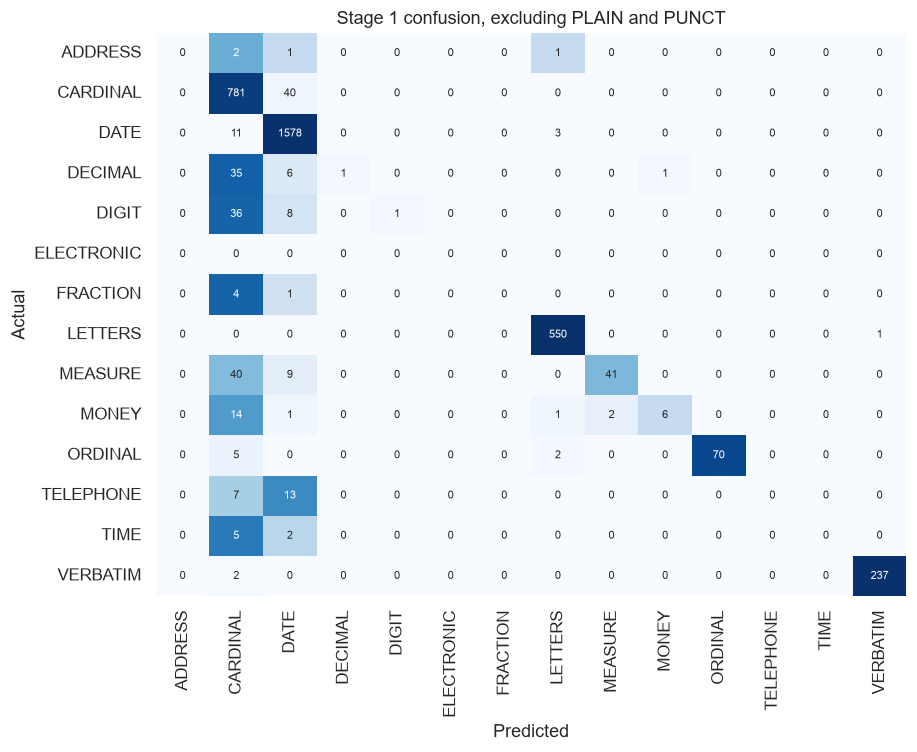

In [31]:
# Which classes get confused with which
interesting = [c for c in sorted(test_df['class'].unique())
               if c not in ('PLAIN', 'PUNCT')]
mask = test_df['class'].isin(interesting).values

cm = confusion_matrix(test_df['class'].values[mask], pred_class_test[mask],
                      labels=interesting)
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
            xticklabels=interesting, yticklabels=interesting, ax=ax,
            annot_kws={'size': 7})
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Stage 1 confusion, excluding PLAIN and PUNCT')
plt.tight_layout()
plt.savefig(ASSETS / 'class_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 5. Stage 2a: rule engine

Given a predicted class, convert the raw token into its spoken form. One handler per class, using `num2words` and `inflect` for number expansion.

The dataset follows specific conventions that generic libraries do not: no `and` in numbers, no hyphens, no commas. `num2words(2006)` returns *two thousand and six* where the dataset expects *two thousand six*. Normalising that is what `strip_and` handles, and getting it wrong was the largest single source of error in the original implementation.

In [32]:
import inflect
from num2words import num2words

p = inflect.engine()

def strip_and(text):
    return text.replace(' and ', ' ').replace('-', ' ').replace(',', '')

def r_cardinal(b):
    c = b.replace(',', '')
    return strip_and(p.number_to_words(int(c))) if c.lstrip('-').isdigit() else b

def r_digit(b):
    c = re.sub(r'[^0-9]', '', b)
    return ' '.join(p.number_to_words(int(d)) for d in c) if c else b

def r_ordinal(b):
    n = re.sub(r'\D', '', b)
    return strip_and(num2words(int(n), to='ordinal')) if n else b

def year_words(y):
    return strip_and(num2words(y, to='year')) if 1000 <= y <= 2099 else str(y)

def r_date(b):
    if re.fullmatch(r'\d{4}', b):
        return year_words(int(b))
    for fmt in ('%d-%b-%y', '%d-%b-%Y', '%d %B %Y', '%d %b %Y',
                '%B %d, %Y', '%b %d, %Y', '%B %Y', '%m/%d/%Y'):
        try:
            o = datetime.strptime(b, fmt)
        except ValueError:
            continue
        month = o.strftime('%B').lower()
        year = year_words(o.year)
        if fmt == '%B %Y':
            return f'{month} {year}'
        day = strip_and(num2words(o.day, to='ordinal'))
        if fmt in ('%B %d, %Y', '%b %d, %Y', '%m/%d/%Y'):
            return f'{month} {day} {year}'
        return f'the {day} of {month} {year}'
    return b

def _expand(number):
    number = number.replace(',', '')
    if '.' in number:
        whole, dec = number.split('.', 1)
        head = strip_and(p.number_to_words(int(whole))) if whole else 'point'
        tail = ' '.join(p.number_to_words(int(d)) for d in dec)
        return f'{head} point {tail}' if whole else f'point {tail}'
    return strip_and(p.number_to_words(int(number)))

def r_money(b):
    cur = {'$': 'dollars', '\u00a3': 'pounds', '\u20ac': 'euros'}
    m = re.match(r'([\u00a3$\u20ac]?)([\d,]+\.?\d*)\s*(million|billion)?', b)
    if not m:
        return b
    base = _expand(m.group(2))
    if m.group(3):
        base += f' {m.group(3).lower()}'
    return f'{base} {cur.get(m.group(1), "")}'.strip()

def r_decimal(b):
    m = re.match(r'([\d.,]+)\s*(million|billion|trillion)?', b.strip(), re.I)
    if not m or m.group(1).count('.') > 1:
        return b
    out = _expand(m.group(1))
    return f'{out} {m.group(2).lower()}' if m.group(2) else out

def r_measure(b):
    units = {
        'm': 'meters', 'km': 'kilometers', 'cm': 'centimeters', 'mm': 'millimeters',
        'kg': 'kilograms', 'g': 'grams', 'mg': 'milligrams', 'GB': 'gigabyte',
        'MB': 'megabyte', '%': 'percent', 'ft': 'feet', 'mi': 'miles',
        'lb': 'pounds', 'lbs': 'pounds', 'nm': 'nanometers', 'ha': 'hectares',
        'ml': 'milliliters', 'yd': 'yards', 'in': 'inches', 's': 'seconds',
        'km/h': 'kilometers per hour', '/km2': 'per square kilometers',
        'km2': 'square kilometers', 'sq mi': 'square miles',
    }
    m = re.match(r'([\d.,]+)\s*(.*)$', b)
    if not m:
        return b
    unit = m.group(2).strip()
    return f'{_expand(m.group(1))} {units.get(unit, unit)}'.strip()

def r_telephone(b):
    out = []
    for ch in b:
        if ch.isdigit():
            out.append(p.number_to_words(int(ch)))
        elif ch in '- ':
            out.append('sil')
    return ' '.join(out).replace('zero', 'o')

def r_electronic(b):
    special = {':': 'colon', '/': 'slash', '.': 'dot', '#': 'hash',
               '-': 'dash', '_': 'underscore', ',': 'comma'}
    out = []
    for ch in b:
        if ch in special:
            out.append(special[ch])
        elif ch.isdigit():
            out.append(p.number_to_words(int(ch)))
        elif ch.isalpha():
            out.append(ch.lower())
    return ' '.join(out)

def r_verbatim(b):
    t = b.strip().lower().replace('.', ' dot ').replace('-', ' dash ')
    return ' '.join(p.number_to_words(int(x)) if x.isdigit() else x
                    for x in t.split())

def r_time(b):
    m = re.match(r'(\d{1,2}):?(\d{2})?\s*([ap])\.?\s*\.?m\.?', b, re.I)
    if m:
        out = strip_and(num2words(int(m.group(1))))
        if m.group(2) and int(m.group(2)):
            out += ' ' + strip_and(num2words(int(m.group(2))))
        return out + (' a m' if m.group(3).lower() == 'a' else ' p m')
    m = re.match(r'(\d{1,2}):(\d{2})', b)
    if m:
        out = strip_and(num2words(int(m.group(1))))
        if int(m.group(2)):
            out += ' ' + strip_and(num2words(int(m.group(2))))
        return out
    return b

def r_letters(b):
    return ' '.join(c.lower() for c in b if c.isalnum())

def r_address(b):
    m = re.match(r'([A-Za-z]*)(\d*)', b.strip())
    if not m:
        return b.lower()
    letters = ' '.join(c.lower() for c in m.group(1))
    digits = ' '.join(p.number_to_words(int(d)) for d in m.group(2))
    return f'{letters} {digits}'.strip()

def r_fraction(b):
    m = re.match(r'(-?\d+)\s*/\s*(\d+)', b)
    if not m:
        return b
    num, den = int(m.group(1)), int(m.group(2))
    num_w = strip_and(p.number_to_words(num))
    den_w = strip_and(num2words(den, to='ordinal'))
    return f'{num_w} {den_w}' + ('s' if abs(num) != 1 else '')

RULES = {
    'PLAIN': lambda x: x, 'PUNCT': lambda x: x,
    'CARDINAL': r_cardinal, 'DIGIT': r_digit, 'ORDINAL': r_ordinal,
    'FRACTION': r_fraction, 'DATE': r_date, 'MONEY': r_money,
    'DECIMAL': r_decimal, 'MEASURE': r_measure, 'TELEPHONE': r_telephone,
    'ELECTRONIC': r_electronic, 'VERBATIM': r_verbatim, 'TIME': r_time,
    'LETTERS': r_letters, 'ADDRESS': r_address,
}

def normalize(before, token_class):
    fn = RULES.get(token_class)
    if fn is None:
        return before
    try:
        return fn(before)
    except Exception:
        return before

print(f'{len(RULES)} class handlers defined.')

16 class handlers defined.


In [33]:
print('Approach 1: rules applied to predicted class')
rule_pred = np.array([normalize(b, c) for b, c
                      in zip(test_df['before'].values, pred_class_test)])
score(rule_pred, 'rules',
      note='Learned class prediction, then hand-written conversion per class.')

Approach 1: rules applied to predicted class
  Overall accuracy:            0.9791
  Transforming-token accuracy: 0.7069


(0.9791136521365544, 0.7069434148752162)

In [34]:
# Rule accuracy per class, to see which handlers are weak
rule_df = test_df.copy()
rule_df['pred'] = rule_pred
rule_df['correct'] = rule_df['pred'] == rule_df['after']

per_class = (rule_df[rule_df['before'] != rule_df['after']]
             .groupby('class', observed=True)
             .agg(tokens=('correct', 'size'), accuracy=('correct', 'mean'))
             .sort_values('tokens', ascending=False))
print(per_class.to_string(float_format='{:.3f}'.format))

            tokens  accuracy
class                       
DATE          1595     0.900
LETTERS        873     0.627
CARDINAL       828     0.908
PLAIN          239     0.000
VERBATIM       164     0.000
MEASURE         93     0.398
ORDINAL         79     0.886
DIGIT           45     0.289
DECIMAL         43     0.070
ELECTRONIC      28     0.000
MONEY           24     0.167
TELEPHONE       20     0.000
TIME             7     0.000
FRACTION         5     0.000
ADDRESS          4     0.000


---
## 6. Stage 2b: memorisation, and why sample size distorts it

The simplest learned alternative to rules is to memorise the mapping: for each written form seen in training, output the spoken form it most often took. Unseen forms fall back to copying.

This is worth measuring for two reasons. It is a strong baseline, since 79% of transforming tokens in held-out data were seen during training. And its behaviour under changing sample size explains a discrepancy in the original project, where the same method scored 82.80%, 84.87% and 92.81% depending only on how much data was used.

In [35]:
def build_lookup(frame):
    table = defaultdict(Counter)
    for b, a in zip(frame['before'].values, frame['after'].values):
        table[b][a] += 1
    return {b: c.most_common(1)[0][0] for b, c in table.items()}

lookup = build_lookup(train_df)
lookup_pred = np.array([lookup.get(b, b) for b in test_df['before'].values])

print('Approach 2: memorised mapping, copy through when unseen')
score(lookup_pred, 'memorisation',
      note='Most frequent spoken form per written form, learned from training data.')

unseen = ~test_df['before'].isin(lookup.keys()).values
print(f'\n  Test tokens unseen in training:              {unseen.mean():.2%}')
print(f'  Transforming test tokens unseen:            {unseen[transforming].mean():.2%}')
print(f'  Distinct spoken forms in the lookup table:  {len(set(lookup.values())):,}')

Approach 2: memorised mapping, copy through when unseen
  Overall accuracy:            0.9723
  Transforming-token accuracy: 0.5854

  Test tokens unseen in training:              15.05%
  Transforming test tokens unseen:            38.47%
  Distinct spoken forms in the lookup table:  29,288


### 6.1 The sample size effect

Training the memorisation table on progressively larger slices, and measuring on the same fixed test set. If accuracy is genuinely improving, it should rise with more data. The output vocabulary is tracked alongside it.

In [36]:
fractions = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0]
train_sentences = train_df['sentence_id'].unique()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_sentences = rng.permutation(train_sentences)

rows = []
for frac in fractions:
    n = max(1, int(len(shuffled_sentences) * frac))
    subset = train_df[train_df['sentence_id'].isin(shuffled_sentences[:n])]
    tbl = build_lookup(subset)
    preds = np.array([tbl.get(b, b) for b in test_df['before'].values])
    correct = preds == truth
    rows.append({
        'train_tokens': len(subset),
        'output_vocab': len(set(subset['after'])),
        'overall': correct.mean(),
        'transforming': correct[transforming].mean(),
        'coverage': subset['before'].nunique(),
    })

curve = pd.DataFrame(rows)
print(curve.to_string(index=False, float_format='{:.4f}'.format))

 train_tokens  output_vocab  overall  transforming  coverage
         6724          3014   0.9538        0.3096      3038
        13603          5350   0.9594        0.3924      5390
        34525         10798   0.9648        0.4742     10887
        69436         17973   0.9686        0.5315     18130
       104108         23862   0.9710        0.5668     24089
       139481         29334   0.9723        0.5854     29615


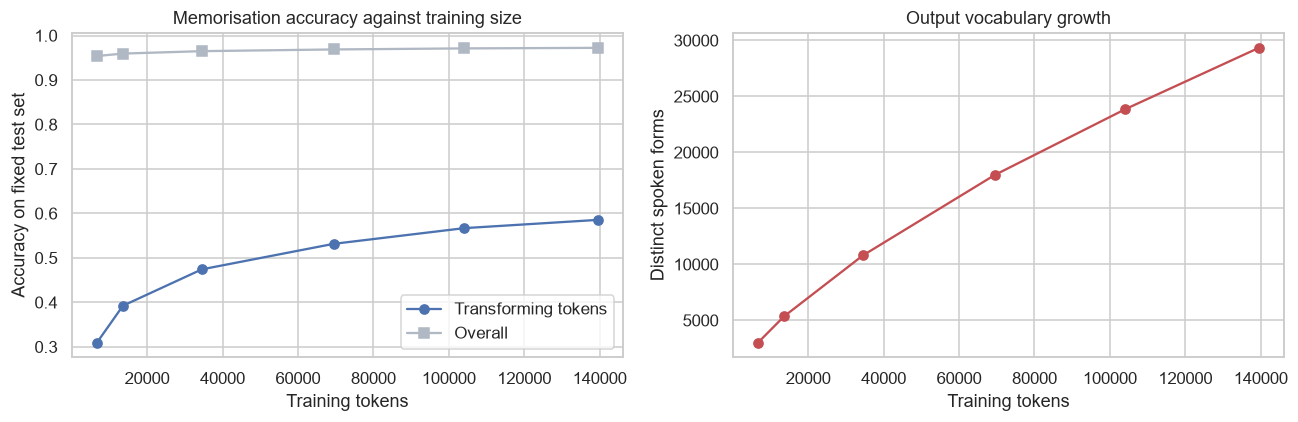

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curve['train_tokens'], curve['transforming'],
             marker='o', color=PRIMARY, label='Transforming tokens')
axes[0].plot(curve['train_tokens'], curve['overall'],
             marker='s', color=MUTED, label='Overall')
axes[0].set_xlabel('Training tokens')
axes[0].set_ylabel('Accuracy on fixed test set')
axes[0].set_title('Memorisation accuracy against training size')
axes[0].legend()

axes[1].plot(curve['train_tokens'], curve['output_vocab'],
             marker='o', color=ACCENT)
axes[1].set_xlabel('Training tokens')
axes[1].set_ylabel('Distinct spoken forms')
axes[1].set_title('Output vocabulary growth')

plt.tight_layout()
plt.savefig(ASSETS / 'sample_size_effect.png', bbox_inches='tight')
plt.show()

RESULTS['sample_size_curve'] = curve.to_dict('records')

The right panel is the important one. The output vocabulary grows steadily with the corpus and shows no sign of saturating, which is what makes direct multiclass prediction over spoken forms unworkable at scale: the number of classes to choose from keeps increasing.

It also explains why a smaller sample can report a higher figure. With fewer distinct spoken forms in play, a classifier is choosing from a shorter list, and a held-out set drawn from the same small pool contains fewer unfamiliar forms. The accuracy improves without the model improving.

---
## 7. Stage 2c: hybrid

Memorisation is accurate where it has coverage, and useless outside it. Rules generalise to any token matching a known pattern, but cannot resolve context-dependent forms. Combining them plays to both.

Routing: use the memorised mapping when the written form was seen in training, otherwise apply the rule engine to the predicted class.

In [38]:
seen_mask = test_df['before'].isin(lookup.keys()).values
hybrid_pred = np.where(seen_mask, lookup_pred, rule_pred)

print('Approach 3: hybrid, memorisation where covered, rules otherwise')
score(hybrid_pred, 'hybrid',
      note='Memorised mapping for seen forms, rule engine for unseen forms.')

print()
for name, mask in [('seen in training', seen_mask), ('unseen', ~seen_mask)]:
    sub = mask & transforming
    if sub.sum():
        print(f'  Transforming tokens {name}: {sub.sum():,} tokens, '
              f'accuracy {(hybrid_pred[sub] == truth[sub]).mean():.4f}')

Approach 3: hybrid, memorisation where covered, rules otherwise
  Overall accuracy:            0.9870
  Transforming-token accuracy: 0.8063

  Transforming tokens seen in training: 2,490 tokens, accuracy 0.9514
  Transforming tokens unseen: 1,557 tokens, accuracy 0.5742


---
## 8. Results

In [39]:
order = ['baseline', 'rules', 'memorisation', 'hybrid']
names = {'baseline': 'Copy through (baseline)',
         'rules': 'Predicted class + rules',
         'memorisation': 'Memorised mapping',
         'hybrid': 'Hybrid (memorisation + rules)'}

summary = pd.DataFrame([
    {'Approach': names[k],
     'Overall': RESULTS[k]['overall'],
     'Transforming tokens': RESULTS[k]['transforming']}
    for k in order if k in RESULTS
])
summary.to_csv(ASSETS / 'results_summary.csv', index=False)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

                     Approach  Overall  Transforming tokens
      Copy through (baseline)   0.9331               0.0000
      Predicted class + rules   0.9791               0.7069
            Memorised mapping   0.9723               0.5854
Hybrid (memorisation + rules)   0.9870               0.8063


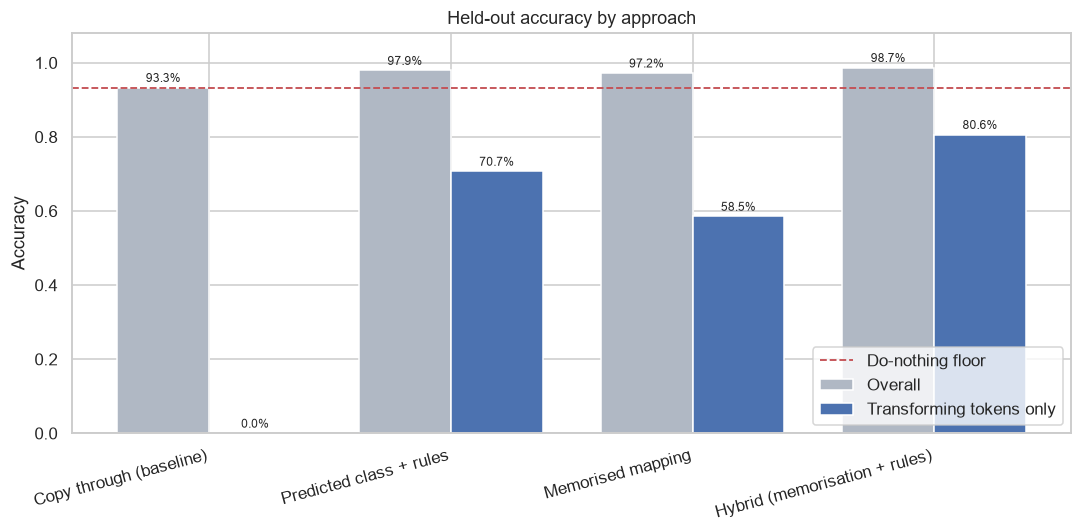

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.38

ax.bar(x - w/2, summary['Overall'], w, label='Overall', color=MUTED)
ax.bar(x + w/2, summary['Transforming tokens'], w,
       label='Transforming tokens only', color=PRIMARY)
ax.axhline(RESULTS['baseline']['overall'], ls='--', c=ACCENT, lw=1.2,
           label='Do-nothing floor')

for i, (o, t) in enumerate(zip(summary['Overall'], summary['Transforming tokens'])):
    ax.text(i - w/2, o + 0.015, f'{o:.1%}', ha='center', fontsize=8)
    ax.text(i + w/2, t + 0.015, f'{t:.1%}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(summary['Approach'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.08)
ax.set_title('Held-out accuracy by approach')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ASSETS / 'accuracy_comparison.png', bbox_inches='tight')
plt.show()

---
## 9. Error analysis
Errors split into two kinds: cases where stage 1 assigned the wrong class, and
cases where the class was right but conversion failed. The split determines
where further effort belongs, since better rules cannot fix a token that was
never routed to them.

In [41]:
err = test_df.copy()
err['predicted'] = hybrid_pred
err['predicted_class'] = pred_class_test
err['correct'] = err['predicted'] == err['after']

mistakes = err[(~err['correct']) & (err['before'] != err['after'])]
print(f'{len(mistakes):,} errors on {transforming.sum():,} transforming tokens\n')

breakdown = (mistakes.groupby('class', observed=True).size()
             .sort_values(ascending=False).to_frame('errors'))
breakdown['share'] = breakdown['errors'] / len(mistakes)
print(breakdown.to_string(float_format='{:.3f}'.format))

784 errors on 4,047 transforming tokens

            errors  share
class                    
LETTERS        274  0.349
DATE           116  0.148
PLAIN          102  0.130
CARDINAL        60  0.077
MEASURE         54  0.069
DECIMAL         35  0.045
DIGIT           31  0.040
ELECTRONIC      26  0.033
VERBATIM        21  0.027
MONEY           20  0.026
TELEPHONE       20  0.026
ORDINAL          9  0.011
TIME             7  0.009
FRACTION         5  0.006
ADDRESS          4  0.005


In [45]:
# Are errors caused by the wrong class, or the right class handled wrongly?
wrong_class = (mistakes['predicted_class'] != mistakes['class']).mean()
print(f'Errors where stage 1 predicted the wrong class: {wrong_class:.2%}')
print(f'Errors where the class was right but conversion failed: {1 - wrong_class:.2%}')
print()
print('Wrong-class errors dominate, so the bottleneck is stage 1 rather than')
print('the rule engine. Several classes showing zero rule accuracy were never')
print('routed to their handler at all.')

RESULTS['errors_from_wrong_class'] = float(wrong_class)

Errors where stage 1 predicted the wrong class: 79.08%
Errors where the class was right but conversion failed: 20.92%

Wrong-class errors dominate, so the bottleneck is stage 1 rather than
the rule engine. Several classes showing zero rule accuracy were never
routed to their handler at all.


In [43]:
cols = ['before', 'class', 'predicted_class', 'after', 'predicted']
mistakes[cols].head(50).to_csv(ASSETS / 'error_examples.csv', index=False)
mistakes[cols].head(25)

,before,class,predicted_class,after,predicted
211,192 1067-8,TELEPHONE,DATE,one nine two sil one o six seven sil eight,192 1067-8
225,:,PLAIN,PUNCT,to,:
688,2000s,DATE,DATE,two thousands,2000s
907,0-7570-0158-0,TELEPHONE,DATE,o sil seven five seven o sil o one five eight ...,0-7570-0158-0
1374,HCG,LETTERS,PLAIN,h c g,HCG
1382,HCG,LETTERS,PLAIN,h c g,HCG
1403,Catalogue,PLAIN,PLAIN,catalog,Catalogue
1694,1½,FRACTION,CARDINAL,one and a half,1½
2443,I,CARDINAL,PLAIN,one,I
2697,-,PLAIN,VERBATIM,to,-


In [44]:
with open(ASSETS / 'metrics.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=str)

print('Saved to ../assets/\n')
print('--- COPY EVERYTHING BELOW THIS LINE ---\n')
print(json.dumps({k: v for k, v in RESULTS.items() if k != 'sample_size_curve'},
                 indent=2, default=str))
print('\nSample size curve:')
print(curve.to_string(index=False, float_format='{:.4f}'.format))
print('\nRule accuracy per class:')
print(per_class.to_string(float_format='{:.3f}'.format))
print('\nError breakdown:')
print(breakdown.to_string(float_format='{:.3f}'.format))

Saved to ../assets/

--- COPY EVERYTHING BELOW THIS LINE ---

{
  "baseline": {
    "overall": 0.9331273340163257,
    "transforming": 0.0,
    "note": "Copies input unchanged. No learning."
  },
  "stage1_class_accuracy": 0.9854092997124823,
  "stage1_class_accuracy_digit_tokens": 0.9054799558661273,
  "rules": {
    "overall": 0.9791136521365544,
    "transforming": 0.7069434148752162,
    "note": "Learned class prediction, then hand-written conversion per class."
  },
  "memorisation": {
    "overall": 0.9722561882415149,
    "transforming": 0.5853718804052385,
    "note": "Most frequent spoken form per written form, learned from training data."
  },
  "hybrid": {
    "overall": 0.987012128622889,
    "transforming": 0.80627625401532,
    "note": "Memorised mapping for seen forms, rule engine for unseen forms."
  },
  "errors_from_wrong_class": 0.7908163265306123
}

Sample size curve:
 train_tokens  output_vocab  overall  transforming  coverage
         6724          3014   0.9538  

---
## 10. Conclusions

**The hybrid wins, and the margin is meaningful.** On tokens that actually require
transformation it reaches 80.63%, against 70.69% for rules alone and 58.54% for
memorisation alone. Overall accuracy is 98.70% against a do-nothing floor of
93.31%, but the transforming-token figure is the one that describes the task.

**Neither component is sufficient alone, and the split shows why.** The hybrid
scores 95.14% on transforming tokens whose written form appeared in training and
57.42% on those it had never seen. Memorisation is close to reliable inside its
coverage and useless outside it, while rules generalise to any token matching a
known pattern but cannot resolve context. Each covers the other's blind spot
rather than the two simply averaging out.

**The bottleneck is classification, not conversion.** 79.08% of remaining errors
occur because stage 1 assigned the wrong class, so the correct handler never ran.
LETTERS is the single largest contributor, with 0.98 precision but 0.59 recall,
accounting for 274 of 784 errors. Acronyms such as BMW, TWA and POUM are being
filed as ordinary words. Several classes that appear to have broken handlers,
TELEPHONE among them, were simply never routed to them: all 20 TELEPHONE tokens
were classified as DATE. This is pursued in `03_classification_improvement.ipynb`.

**Sample size distorts the headline number.** Section 6.1 shows memorisation
accuracy on a fixed test set rising from 30.96% to 58.54% purely as training data
grows from 6,724 to 139,481 tokens, while the output vocabulary grows from 3,014
to 29,334 distinct spoken forms with no sign of saturating. Any accuracy figure
for this task is only interpretable alongside the corpus size it was measured on,
which is why results reported on small samples can look stronger than they are.

### Known limitations

- Tokens are treated independently. The EDA established that 33.76% of
  transforming tokens have written forms mapping to more than one spoken form
  depending on context, and nothing in this pipeline can resolve those. That is a
  ceiling, not a tuning problem.
- 38.47% of transforming tokens in this split were unseen during training, higher
  than the 20.98% measured in the EDA on a larger probe. Smaller training data
  means less coverage, so results here understate what the same design would
  achieve on the full corpus.
- The rule engine encodes English conventions specific to this dataset and would
  need rewriting for another language, which is precisely the cost the learned
  approach was meant to remove.
- Evaluation uses a 200,000 token sample. Class shares track the full corpus
  within 0.17 percentage points, but rare classes have very few test examples:
  ADDRESS has 4, FRACTION 5, TIME 7. Per-class figures for those are indicative
  at best.
- Sequence models were not attempted. Given that ambiguity is the binding
  constraint, a model with access to surrounding tokens is the obvious next step.